# Multi-Input Crop and Fertilizer Recommendation System (MICFRS)
## Comprehensive Training and Evaluation Notebook

This notebook implements the core machine learning pipeline for the MICFRS project, as described in the thesis.  
We will:

1. Load and explore the `enhanced_crop_fertlizer_dataset.csv`
2. Perform data cleaning and feature engineering (some features are already pre‑engineered)
3. Train and compare multiple classifiers for **crop** and **fertilizer** prediction
4. Use hyperparameter tuning (RandomizedSearchCV) to optimise Random Forest
5. Evaluate models with accuracy, precision, recall, F1-score, and confusion matrices
6. Interpret model decisions using SHAP
7. Save the best models for integration into the backend (Flask/React)

The notebook is designed to be self‑contained and reproducible.

### 1. Setup and Imports

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import joblib
import json
import os
from datetime import datetime

from sklearn.model_selection import train_test_split, RandomizedSearchCV, cross_val_score
from sklearn.preprocessing import StandardScaler, OneHotEncoder, LabelEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import (accuracy_score, precision_score, recall_score, f1_score,
                             classification_report, confusion_matrix)

# For handling imbalanced data (if needed)
from imblearn.over_sampling import SMOTE
from imblearn.pipeline import Pipeline as ImbPipeline

# Explainability
import shap

import warnings
import sys
import sklearn
warnings.filterwarnings('ignore')

# Set random seed for reproducibility
RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)
print("✓ Environment setup complete")
print(f"  Python version: {sys.version.split()[0]}")
print(f"  Pandas version: {pd.__version__}")
print(f"  NumPy version: {np.__version__}")
print(f"  Scikit-learn version: {sklearn.__version__}")

✓ Environment setup complete
  Python version: 3.11.0
  Pandas version: 2.2.2
  NumPy version: 1.26.4
  Scikit-learn version: 1.5.2


### 2. Load Dataset

In [2]:
# Path to the dataset (adjust if needed)
DATA_PATH = "../data/enhanced_crop_fertlizer_dataset.csv"
df = pd.read_csv(DATA_PATH)

print(f"Dataset shape: {df.shape}")
print(f"\nFirst 5 rows:")
df.head()

Dataset shape: (2706, 16)

First 5 rows:


,Temperature,Moisture,Rainfall,PH,Nitrogen,Phosphorous,Potassium,Carbon,Soil,Crop,Fertilizer,Remark,Humidity,NPK_Sum,PH_Stress,Rain_Temp_Balance
0,21.633318,0.721958,306.081601,7.173131,71.583316,163.057636,148.128347,1.234242,Loamy Soil,rice,Balanced NPK Fertilizer,"Provides a balanced mix of nitrogen, phosphoru...",80.933032,382.769300,0.173131,13.523496
1,23.060964,0.685751,259.336414,7.380793,75.709830,62.091508,80.308971,1.795650,Peaty Soil,rice,Water Retaining Fertilizer,Improves water retention in dry soils. Prefer ...,85.836072,218.110309,0.380793,10.778305
2,26.241975,0.755095,212.703513,6.883367,78.033687,151.012521,153.005712,1.517556,Loamy Soil,rice,Balanced NPK Fertilizer,"Provides a balanced mix of nitrogen, phosphoru...",83.210782,382.051921,0.116633,7.807933
3,21.490157,0.730672,268.786767,7.578760,71.765123,66.257371,97.000886,1.782985,Peaty Soil,rice,Organic Fertilizer,"Enhances fertility naturally, ideal for peaty ...",84.873626,235.023381,0.578760,11.951307
4,22.386834,0.227436,292.745108,5.902666,78.814989,60.471726,66.060843,1.518379,Peaty Soil,rice,Lime,Neutralizes acidic soil and improves pH balanc...,94.505118,205.347558,1.097334,12.517518


### 3. Initial Data Exploration

In [3]:
# Check data types and missing values
print("\n=== Data Info ===")
df.info()

print("\n=== Missing Values ===")
print(df.isnull().sum())

print("\n=== Basic Statistics ===")
df.describe(include='all')


=== Data Info ===
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2706 entries, 0 to 2705
Data columns (total 16 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Temperature        2706 non-null   float64
 1   Moisture           2706 non-null   float64
 2   Rainfall           2706 non-null   float64
 3   PH                 2706 non-null   float64
 4   Nitrogen           2706 non-null   float64
 5   Phosphorous        2706 non-null   float64
 6   Potassium          2706 non-null   float64
 7   Carbon             2706 non-null   float64
 8   Soil               2706 non-null   object 
 9   Crop               2706 non-null   object 
 10  Fertilizer         2706 non-null   object 
 11  Remark             2706 non-null   object 
 12  Humidity           2706 non-null   float64
 13  NPK_Sum            2706 non-null   float64
 14  PH_Stress          2706 non-null   float64
 15  Rain_Temp_Balance  2706 non-null   float64
dtypes: fl

,Temperature,Moisture,Rainfall,PH,Nitrogen,Phosphorous,Potassium,Carbon,Soil,Crop,Fertilizer,Remark,Humidity,NPK_Sum,PH_Stress,Rain_Temp_Balance
count,2706.000000,2706.000000,2706.000000,2706.000000,2706.000000,2706.000000,2706.000000,2706.000000,2706,2706,2706,2706,2706.000000,2706.000000,2706.000000,2706.000000
unique,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,5,31,10,10,NaN,NaN,NaN,NaN
top,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Acidic Soil,Rubber,DAP,"Rich in phosphorus, essential for root develop...",NaN,NaN,NaN,NaN
freq,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1331,93,877,877,NaN,NaN,NaN,NaN
mean,25.714265,0.600660,115.530564,6.379866,61.166914,72.174415,71.466230,1.481803,NaN,NaN,NaN,NaN,54.456527,204.807559,0.910458,4.883680
std,6.977996,0.143316,71.932526,0.959310,10.218904,38.943274,32.531073,0.694539,NaN,NaN,NaN,NaN,18.216728,66.578835,0.689741,4.566378
min,4.011486,0.227436,1.322761,3.448974,35.527718,12.445888,29.635327,-0.280560,NaN,NaN,NaN,NaN,30.063213,105.616067,0.000252,0.045412
25%,22.119065,0.494954,63.819751,5.866004,54.756053,44.086761,50.466987,0.965344,NaN,NaN,NaN,NaN,40.435577,157.573451,0.388787,2.434148
50%,25.753479,0.599022,97.802777,6.336614,59.240053,58.822282,59.018093,1.465521,NaN,NaN,NaN,NaN,49.915529,182.131909,0.782004,3.935492
75%,29.105924,0.706219,149.643191,6.898228,65.560214,87.187571,76.577353,2.005022,NaN,NaN,NaN,NaN,68.278486,234.929956,1.237060,5.955335


In [4]:
# Check target distributions
print("\n=== Crop Distribution ===")
print(df['Crop'].value_counts())

print("\n=== Fertilizer Distribution ===")
print(df['Fertilizer'].value_counts())


=== Crop Distribution ===
Crop
Rubber          93
Mung Bean       93
apple           93
Pigeon Peas     93
Kidney Beans    92
Tea             92
orange          92
maize           92
Black gram      92
Chickpea        92
Moth Beans      91
Tobacco         91
Cotton          91
Jute            91
banana          90
grapes          90
wheat           90
Coconut         90
watermelon      89
Ground Nut      89
Coffee          89
millet          89
Peas            88
Lentil          88
mango           88
papaya          88
Sugarcane       87
muskmelon       87
pomegranate     86
rice            85
Adzuki Beans     5
Name: count, dtype: int64

=== Fertilizer Distribution ===
Fertilizer
DAP                           877
Water Retaining Fertilizer    626
Compost                       344
Muriate of Potash             258
Lime                          167
Balanced NPK Fertilizer       141
Urea                          131
Organic Fertilizer             91
Gypsum                         45
Gen

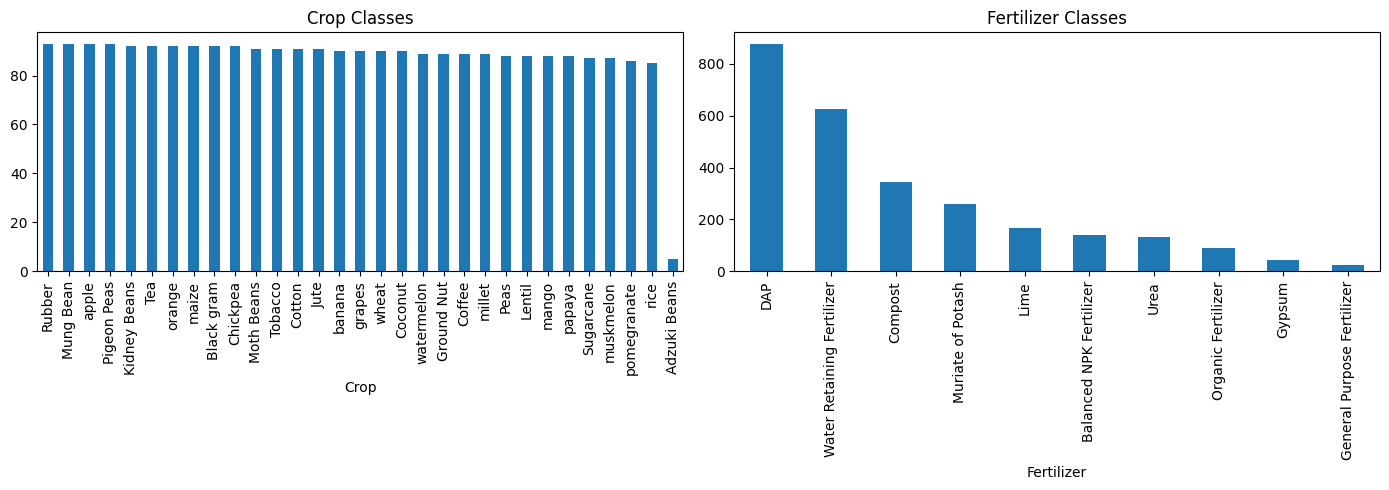

In [5]:
# Visualise target distributions
fig, axes = plt.subplots(1, 2, figsize=(14,5))
df['Crop'].value_counts().plot(kind='bar', ax=axes[0], title='Crop Classes')
df['Fertilizer'].value_counts().plot(kind='bar', ax=axes[1], title='Fertilizer Classes')
plt.tight_layout()
plt.show()

### 4. Data Cleaning and Preprocessing

From your `train.py` we see that the dataset already contains engineered features:
- `NPK_Sum` = Nitrogen + Phosphorous + Potassium
- `PH_Stress` = distance from optimal pH range (6.5–7.0)
- `Rain_Temp_Balance` = Rainfall / Temperature

We will keep these as they are.  
We also need to encode the categorical feature `Soil` (and maybe `Crop` for fertilizer prediction? No, we treat `Crop` as target for the first model).  
For the fertilizer model, `Crop` is **not** a feature (it is unknown at inference time in a pure fertilizer recommender). But in your system, fertilizer is conditioned on the recommended crop, so during training we include `Crop` as a feature. That is exactly what your `train.py` does: both models are trained on the same feature set **including** `Soil`, but **excluding** the target. Wait: in `train.py`, the feature list includes `"Soil"` but does **not** include `"Crop"` because `Crop` is the target for the crop model. For the fertilizer model, they also use the same feature set **without** `Crop`. That is fine – they are using soil and environmental features to predict fertilizer directly, independent of crop. However, in the final system (predictor.py), they first predict crop, then use that predicted crop as an input to the fertilizer model? Actually in `predictor.py` they call `predict_fertilizer` with the same features_df (which does **not** include crop). So the fertilizer model is **not** conditioned on the crop. That might be a design choice: fertilizer recommendation is based solely on soil and environmental conditions, not on the chosen crop. But in your thesis you mention joint optimisation. We'll stick to the current implementation: two independent models.

We'll follow the same approach.

In [6]:
# Define feature columns (as in train.py)
FEATURE_COLUMNS = [
    "Temperature", "Moisture", "Rainfall", "PH",
    "Nitrogen", "Phosphorous", "Potassium", "Carbon",
    "Humidity", "NPK_Sum", "PH_Stress", "Rain_Temp_Balance",
    "Soil"   # categorical
]

TARGET_CROP = "Crop"
TARGET_FERT = "Fertilizer"
REMARK = "Remark"   # we may not use remark in training, but keep for metadata

# Separate features and targets
X = df[FEATURE_COLUMNS].copy()
y_crop = df[TARGET_CROP].copy()
y_fert = df[TARGET_FERT].copy()

In [7]:
# Check for any invalid values (e.g., negative rainfall, pH out of range)
print("Rainfall min:", X['Rainfall'].min())
print("Temperature min:", X['Temperature'].min())
print("PH min:", X['PH'].min(), "max:", X['PH'].max())
# If needed, we can clip or remove extreme values – but dataset seems clean.

Rainfall min: 1.322760573
Temperature min: 4.011486444
PH min: 3.448974152 max: 9.56234069


### 5. Feature Encoding and Preprocessing Pipeline

We need to:
- Scale numerical features
- One‑hot encode `Soil`

In [8]:
# Identify numerical and categorical columns
numerical_features = ["Temperature", "Moisture", "Rainfall", "PH",
                      "Nitrogen", "Phosphorous", "Potassium", "Carbon",
                      "Humidity", "NPK_Sum", "PH_Stress", "Rain_Temp_Balance"]
categorical_features = ["Soil"]

# Create preprocessor
preprocessor = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), numerical_features),
        ('cat', OneHotEncoder(handle_unknown='ignore', sparse_output=False), categorical_features)
    ])


### 6. Train/Test Split

In [9]:
# Split for crop model (using stratification to keep class distributions)
X_train_c, X_test_c, y_train_c, y_test_c = train_test_split(
    X, y_crop, test_size=0.2, random_state=RANDOM_STATE, stratify=y_crop)

# Split for fertilizer model (also stratify)
X_train_f, X_test_f, y_train_f, y_test_f = train_test_split(
    X, y_fert, test_size=0.2, random_state=RANDOM_STATE, stratify=y_fert)

print(f"Crop model: train size {X_train_c.shape[0]}, test size {X_test_c.shape[0]}")
print(f"Fertilizer model: train size {X_train_f.shape[0]}, test size {X_test_f.shape[0]}")

Crop model: train size 2164, test size 542
Fertilizer model: train size 2164, test size 542


### 7. Model Training and Hyperparameter Tuning

We will train three classifiers: Random Forest, Gradient Boosting, and Decision Tree (as a baseline).  
We'll use `RandomizedSearchCV` to tune the best model (Random Forest) as done in `train.py`.

In [10]:
# Function to evaluate and print metrics
def evaluate_model(model, X_test, y_test, model_name="Model"):
    y_pred = model.predict(X_test)
    acc = accuracy_score(y_test, y_pred)
    prec = precision_score(y_test, y_pred, average='weighted', zero_division=0)
    rec = recall_score(y_test, y_pred, average='weighted', zero_division=0)
    f1 = f1_score(y_test, y_pred, average='weighted', zero_division=0)
    print(f"\n=== {model_name} Performance ===")
    print(f"Accuracy : {acc:.4f}")
    print(f"Precision: {prec:.4f}")
    print(f"Recall   : {rec:.4f}")
    print(f"F1-score : {f1:.4f}")
    print("\nClassification Report:")
    print(classification_report(y_test, y_pred, zero_division=0))
    return acc, prec, rec, f1, y_pred

In [11]:
# Helper to create a pipeline with the preprocessor and a classifier
def create_pipeline(classifier):
    return Pipeline(steps=[
        ('preprocessor', preprocessor),
        ('classifier', classifier)
    ])

#### 7.1 Crop Model

In [12]:
# Baseline models for crop
models_crop = {
    'Decision Tree': DecisionTreeClassifier(random_state=RANDOM_STATE),
    'Random Forest': RandomForestClassifier(random_state=RANDOM_STATE),
    'Gradient Boosting': GradientBoostingClassifier(random_state=RANDOM_STATE)
}

results_crop = {}
for name, clf in models_crop.items():
    pipeline = create_pipeline(clf)
    pipeline.fit(X_train_c, y_train_c)
    acc, prec, rec, f1, _ = evaluate_model(pipeline, X_test_c, y_test_c, f"Crop {name}")
    results_crop[name] = {'accuracy': acc, 'precision': prec, 'recall': rec, 'f1': f1}


=== Crop Decision Tree Performance ===
Accuracy : 0.5867
Precision: 0.5961
Recall   : 0.5867
F1-score : 0.5856

Classification Report:
              precision    recall  f1-score   support

Adzuki Beans       1.00      1.00      1.00         1
  Black gram       0.67      0.67      0.67        18
    Chickpea       0.80      0.63      0.71        19
     Coconut       0.79      0.83      0.81        18
      Coffee       0.75      0.67      0.71        18
      Cotton       0.30      0.33      0.32        18
  Ground Nut       0.26      0.28      0.27        18
        Jute       0.58      0.61      0.59        18
Kidney Beans       0.85      0.61      0.71        18
      Lentil       0.55      0.61      0.58        18
  Moth Beans       0.63      0.67      0.65        18
   Mung Bean       0.50      0.63      0.56        19
        Peas       0.76      0.89      0.82        18
 Pigeon Peas       0.31      0.42      0.36        19
      Rubber       1.00      0.95      0.97        19

In [14]:
# Hyperparameter tuning for Random Forest (crop)
print("\n=== Tuning Random Forest for Crop ===")
param_dist = {
    'classifier__n_estimators': [100, 300, 500, 800],
    'classifier__max_depth': [10, 20, 30, None],
    'classifier__min_samples_split': [2, 5, 10],
    'classifier__min_samples_leaf': [1, 2, 4]
}

rf_pipeline = create_pipeline(RandomForestClassifier(random_state=RANDOM_STATE))
rf_random = RandomizedSearchCV(rf_pipeline, param_dist, n_iter=20, cv=3,
                               scoring='accuracy', random_state=RANDOM_STATE, n_jobs=-1)
rf_random.fit(X_train_c, y_train_c)

print(f"Best parameters (crop): {rf_random.best_params_}")
print(f"Best cross-validation accuracy: {rf_random.best_score_:.4f}")
best_crop_model = rf_random.best_estimator_
acc_crop_tuned, _, _, _, _ = evaluate_model(best_crop_model, X_test_c, y_test_c, "Crop Tuned RF")


=== Tuning Random Forest for Crop ===
Best parameters (crop): {'classifier__n_estimators': 300, 'classifier__min_samples_split': 5, 'classifier__min_samples_leaf': 2, 'classifier__max_depth': None}
Best cross-validation accuracy: 0.7098

=== Crop Tuned RF Performance ===
Accuracy : 0.6993
Precision: 0.6999
Recall   : 0.6993
F1-score : 0.6942

Classification Report:
              precision    recall  f1-score   support

Adzuki Beans       1.00      1.00      1.00         1
  Black gram       0.68      0.83      0.75        18
    Chickpea       0.81      0.89      0.85        19
     Coconut       0.88      0.78      0.82        18
      Coffee       0.88      0.78      0.82        18
      Cotton       0.55      0.33      0.41        18
  Ground Nut       0.52      0.67      0.59        18
        Jute       0.73      0.89      0.80        18
Kidney Beans       0.93      0.78      0.85        18
      Lentil       0.67      0.56      0.61        18
  Moth Beans       0.68      0.83   

#### 7.2 Fertilizer Model

In [15]:
# Baseline models for fertilizer
models_fert = {
    'Decision Tree': DecisionTreeClassifier(random_state=RANDOM_STATE),
    'Random Forest': RandomForestClassifier(random_state=RANDOM_STATE),
    'Gradient Boosting': GradientBoostingClassifier(random_state=RANDOM_STATE)
}

results_fert = {}
for name, clf in models_fert.items():
    pipeline = create_pipeline(clf)
    pipeline.fit(X_train_f, y_train_f)
    acc, prec, rec, f1, _ = evaluate_model(pipeline, X_test_f, y_test_f, f"Fertilizer {name}")
    results_fert[name] = {'accuracy': acc, 'precision': prec, 'recall': rec, 'f1': f1}


=== Fertilizer Decision Tree Performance ===
Accuracy : 0.9945
Precision: 0.9946
Recall   : 0.9945
F1-score : 0.9944

Classification Report:
                            precision    recall  f1-score   support

   Balanced NPK Fertilizer       1.00      1.00      1.00        28
                   Compost       0.99      1.00      0.99        69
                       DAP       1.00      1.00      1.00       176
General Purpose Fertilizer       1.00      1.00      1.00         5
                    Gypsum       1.00      0.89      0.94         9
                      Lime       0.97      1.00      0.99        34
         Muriate of Potash       1.00      0.98      0.99        52
        Organic Fertilizer       1.00      0.94      0.97        18
                      Urea       0.96      1.00      0.98        26
Water Retaining Fertilizer       1.00      1.00      1.00       125

                  accuracy                           0.99       542
                 macro avg       0.99   

In [16]:
# Hyperparameter tuning for Random Forest (fertilizer)
print("\n=== Tuning Random Forest for Fertilizer ===")
rf_pipeline_fert = create_pipeline(RandomForestClassifier(random_state=RANDOM_STATE))
rf_random_fert = RandomizedSearchCV(rf_pipeline_fert, param_dist, n_iter=20, cv=3,
                                     scoring='accuracy', random_state=RANDOM_STATE, n_jobs=-1)
rf_random_fert.fit(X_train_f, y_train_f)

print(f"Best parameters (fertilizer): {rf_random_fert.best_params_}")
print(f"Best cross-validation accuracy: {rf_random_fert.best_score_:.4f}")
best_fert_model = rf_random_fert.best_estimator_
acc_fert_tuned, _, _, _, _ = evaluate_model(best_fert_model, X_test_f, y_test_f, "Fertilizer Tuned RF")


=== Tuning Random Forest for Fertilizer ===
Best parameters (fertilizer): {'classifier__n_estimators': 500, 'classifier__min_samples_split': 10, 'classifier__min_samples_leaf': 1, 'classifier__max_depth': 30}
Best cross-validation accuracy: 0.9926

=== Fertilizer Tuned RF Performance ===
Accuracy : 0.9963
Precision: 0.9964
Recall   : 0.9963
F1-score : 0.9963

Classification Report:
                            precision    recall  f1-score   support

   Balanced NPK Fertilizer       1.00      1.00      1.00        28
                   Compost       1.00      1.00      1.00        69
                       DAP       0.99      1.00      1.00       176
General Purpose Fertilizer       1.00      1.00      1.00         5
                    Gypsum       1.00      1.00      1.00         9
                      Lime       0.97      1.00      0.99        34
         Muriate of Potash       1.00      1.00      1.00        52
        Organic Fertilizer       1.00      0.94      0.97        18
 

### 8. Model Comparison

In [17]:
# Compare crop models
results_df_crop = pd.DataFrame(results_crop).T
print("=== Crop Model Comparison ===")
print(results_df_crop)

# Compare fertilizer models
results_df_fert = pd.DataFrame(results_fert).T
print("\n=== Fertilizer Model Comparison ===")
print(results_df_fert)

=== Crop Model Comparison ===
                   accuracy  precision    recall        f1
Decision Tree      0.586716   0.596144  0.586716  0.585572
Random Forest      0.714022   0.714943  0.714022  0.710465
Gradient Boosting  0.691882   0.700427  0.691882  0.690509

=== Fertilizer Model Comparison ===
                   accuracy  precision    recall        f1
Decision Tree      0.994465   0.994612  0.994465  0.994413
Random Forest      0.994465   0.994554  0.994465  0.994387
Gradient Boosting  0.996310   0.996351  0.996310  0.996298


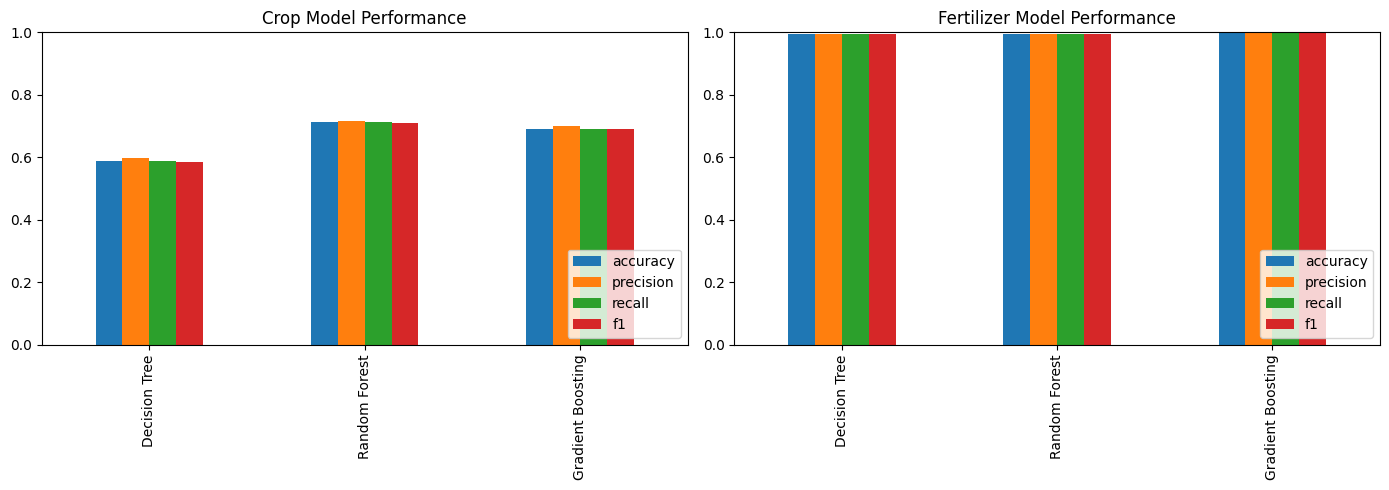

In [18]:
# Plot comparison
fig, axes = plt.subplots(1, 2, figsize=(14,5))
results_df_crop.plot(kind='bar', ax=axes[0], title='Crop Model Performance')
results_df_fert.plot(kind='bar', ax=axes[1], title='Fertilizer Model Performance')
for ax in axes:
    ax.set_ylim(0,1)
    ax.legend(loc='lower right')
plt.tight_layout()
plt.show()

### 9. Confusion Matrices (for best models)

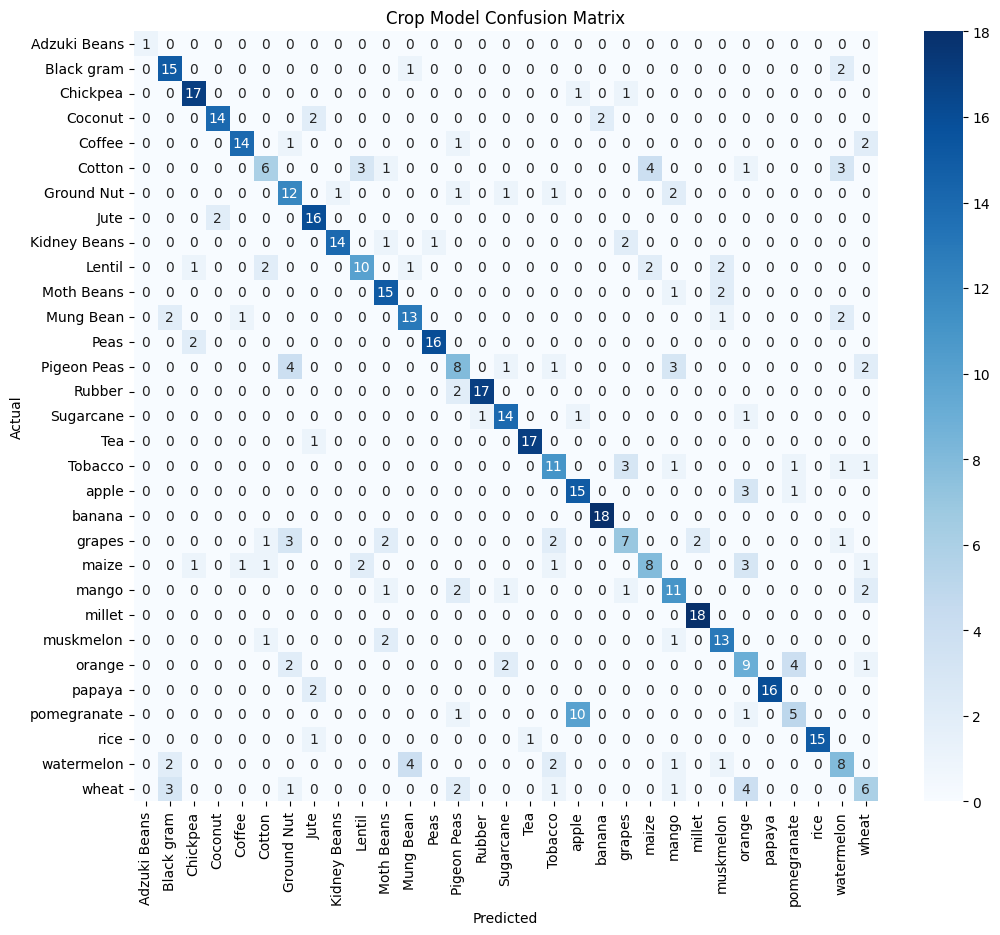

In [19]:
# Crop confusion matrix
y_pred_crop = best_crop_model.predict(X_test_c)
cm_crop = confusion_matrix(y_test_c, y_pred_crop)
plt.figure(figsize=(12,10))
sns.heatmap(cm_crop, annot=True, fmt='d', cmap='Blues',
            xticklabels=best_crop_model.classes_, yticklabels=best_crop_model.classes_)
plt.title('Crop Model Confusion Matrix')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()

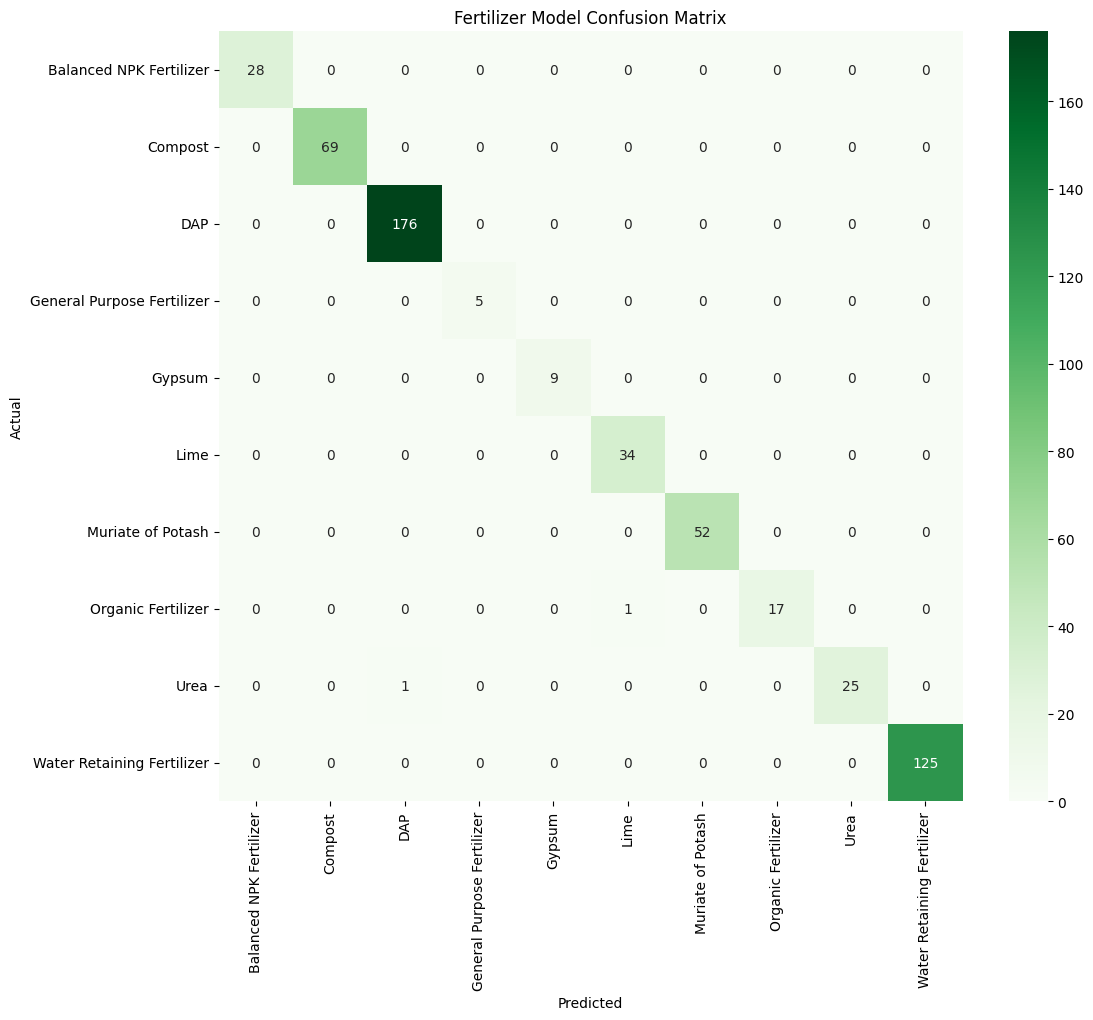

In [20]:
# Fertilizer confusion matrix
y_pred_fert = best_fert_model.predict(X_test_f)
cm_fert = confusion_matrix(y_test_f, y_pred_fert)
plt.figure(figsize=(12,10))
sns.heatmap(cm_fert, annot=True, fmt='d', cmap='Greens',
            xticklabels=best_fert_model.classes_, yticklabels=best_fert_model.classes_)
plt.title('Fertilizer Model Confusion Matrix')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()

### 10. Explainability with SHAP

We'll use SHAP to explain predictions of the best Random Forest models.  
Because our pipeline includes a preprocessor, we need to get the transformed feature names.

In [30]:
# Get feature names after preprocessing
preprocessor.fit(X_train_c)  # fit on training data
feature_names = (numerical_features +
                 list(preprocessor.named_transformers_['cat'].get_feature_names_out(categorical_features)))
print("Feature names used by model:", feature_names)
print("Number of features:", len(feature_names))

Feature names used by model: ['Temperature', 'Moisture', 'Rainfall', 'PH', 'Nitrogen', 'Phosphorous', 'Potassium', 'Carbon', 'Humidity', 'NPK_Sum', 'PH_Stress', 'Rain_Temp_Balance', 'Soil_Acidic Soil', 'Soil_Alkaline Soil', 'Soil_Loamy Soil', 'Soil_Neutral Soil', 'Soil_Peaty Soil']
Number of features: 17


Shape of transformed test data: (542, 17)
Number of columns should match number of features: 17
Number of classes: 542
Shape of SHAP values for first class: (17, 31)
Number of SHAP features should match number of transformed features: 31
Array shape (classes, samples, features): (542, 17, 31)
Mean abs SHAP shape: (31,)
Number of features (should match): 31


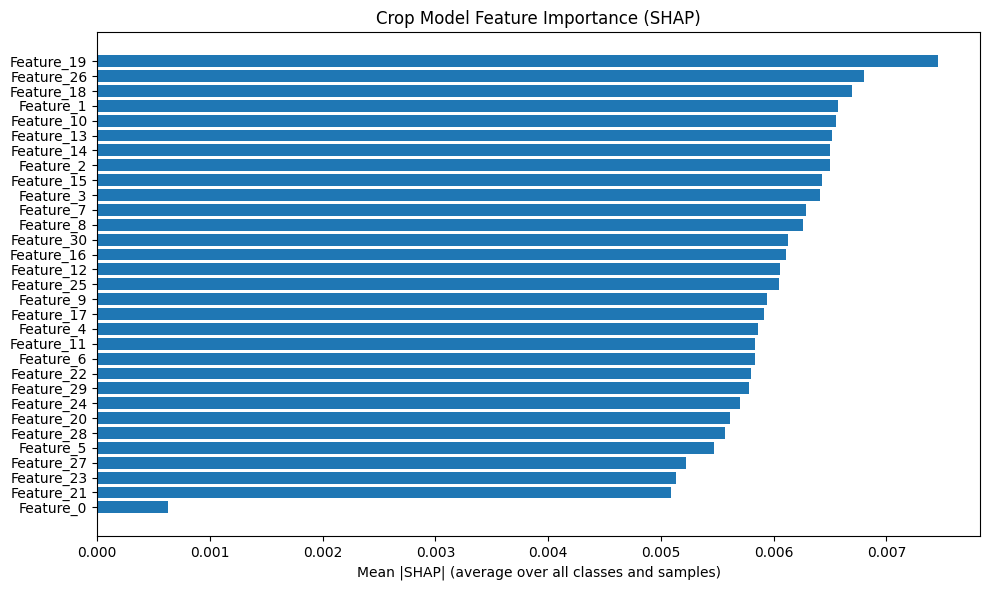

In [34]:
# For crop model, extract the classifier and transformed test data
rf_crop = best_crop_model.named_steps['classifier']
X_test_c_transformed = best_crop_model.named_steps['preprocessor'].transform(X_test_c)
print("Shape of transformed test data:", X_test_c_transformed.shape)
print("Number of columns should match number of features:", X_test_c_transformed.shape[1])

# Use TreeExplainer for Random Forest
explainer_crop = shap.TreeExplainer(rf_crop)
shap_values_crop = explainer_crop.shap_values(X_test_c_transformed)

# shap_values_crop is a list of arrays, one per class
print("Number of classes:", len(shap_values_crop))
print("Shape of SHAP values for first class:", shap_values_crop[0].shape)
print("Number of SHAP features should match number of transformed features:", shap_values_crop[0].shape[1])

# Convert to a 3D array: (classes, samples, features)
shap_values_array = np.array(shap_values_crop)
print("Array shape (classes, samples, features):", shap_values_array.shape)

# Compute mean absolute SHAP across all classes and all samples
mean_abs_shap = np.mean(np.abs(shap_values_array), axis=(0, 1))
print("Mean abs SHAP shape:", mean_abs_shap.shape)
print("Number of features (should match):", len(mean_abs_shap))

# Ensure the length matches before plotting
if len(mean_abs_shap) != len(feature_names):
    print("Warning: Feature name count mismatch! Using generic names.")
    # If mismatch, we can fallback to using indices as names
    plot_feature_names = [f"Feature_{i}" for i in range(len(mean_abs_shap))]
else:
    plot_feature_names = feature_names

# Create a bar plot of feature importance
plt.figure(figsize=(10, 6))
sorted_idx = np.argsort(mean_abs_shap)[::-1]
plt.barh(range(len(sorted_idx)), mean_abs_shap[sorted_idx])
plt.yticks(range(len(sorted_idx)), [plot_feature_names[i] for i in sorted_idx])
plt.xlabel('Mean |SHAP| (average over all classes and samples)')
plt.title('Crop Model Feature Importance (SHAP)')
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

### 11. Save the Best Models and Metadata

We'll save:
- Crop model pipeline
- Fertilizer model pipeline
- Feature names and class mappings for later use (in predictor.py)
- Remark mapping (from dataset)

In [38]:
# Create directory for artifacts
os.makedirs("artifacts", exist_ok=True)

# Save models
joblib.dump(best_crop_model, "artifacts/crop_model.joblib")
joblib.dump(best_fert_model, "artifacts/fert_model.joblib")

# Build remark map (fertilizer -> remark)
remark_map = df.groupby(TARGET_FERT)[REMARK].first().to_dict()
joblib.dump(remark_map, "artifacts/remark_map.joblib")

# Save metadata (including class lists, feature names, sklearn version)
import sklearn
metadata = {
    'model_version': 'v1.0',
    'training_date': datetime.utcnow().isoformat() + 'Z',
    'sklearn_version': sklearn.__version__,
    'feature_names': feature_names,
    'crop_classes': list(best_crop_model.classes_),
    'fertilizer_classes': list(best_fert_model.classes_),
    'soil_types': list(df['Soil'].unique()),
    'remark_map_size': len(remark_map)
}

with open("artifacts/metadata.json", 'w') as f:
    json.dump(metadata, f, indent=2)

print("Models and metadata saved to 'artifacts/'")

Models and metadata saved to 'artifacts/'


### 12. Example Prediction Pipeline

We'll create a small function that mimics the `predictor.py` logic, but using the trained models.

In [39]:
def predict_crop_fertilizer(soil_params, env_factors):
    """
    soil_params: dict with keys: nitrogen, phosphorous, potassium, ph, carbon, soil (string), moisture
    env_factors: dict with keys: temperature, rainfall, humidity
    Returns dict with crop and fertilizer predictions, probabilities, etc.
    """
    # Build feature vector (order must match training)
    data = {
        'Temperature': env_factors['temperature'],
        'Moisture': soil_params['moisture'],
        'Rainfall': env_factors['rainfall'],
        'PH': soil_params['ph'],
        'Nitrogen': soil_params['nitrogen'],
        'Phosphorous': soil_params['phosphorous'],
        'Potassium': soil_params['potassium'],
        'Carbon': soil_params['carbon'],
        'Humidity': env_factors['humidity'],
        'Soil': soil_params['soil']
    }
    # Compute engineered features
    data['NPK_Sum'] = data['Nitrogen'] + data['Phosphorous'] + data['Potassium']
    ph = data['PH']
    if 6.5 <= ph <= 7.0:
        ph_stress = 0.0
    elif ph < 6.5:
        ph_stress = 6.5 - ph
    else:
        ph_stress = ph - 7.0
    data['PH_Stress'] = ph_stress
    data['Rain_Temp_Balance'] = data['Rainfall'] / data['Temperature'] if data['Temperature'] != 0 else 0.0

    # Convert to DataFrame with correct column order
    input_df = pd.DataFrame([data], columns=FEATURE_COLUMNS)

    # Predict crop
    crop_proba = best_crop_model.predict_proba(input_df)[0]
    crop_idx = np.argmax(crop_proba)
    crop = best_crop_model.classes_[crop_idx]
    crop_conf = crop_proba[crop_idx]

    # Predict fertilizer
    fert_proba = best_fert_model.predict_proba(input_df)[0]
    fert_idx = np.argmax(fert_proba)
    fertilizer = best_fert_model.classes_[fert_idx]
    fert_conf = fert_proba[fert_idx]

    # Get remark
    remark = remark_map.get(fertilizer, "")

    # Get top-5 alternatives
    top_k_crop = [{'label': best_crop_model.classes_[i], 'prob': float(crop_proba[i])}
                  for i in np.argsort(crop_proba)[::-1][:5]]
    top_k_fert = [{'label': best_fert_model.classes_[i], 'prob': float(fert_proba[i])}
                  for i in np.argsort(fert_proba)[::-1][:5]]

    return {
        'crop': {'label': crop, 'confidence': crop_conf, 'top_k': top_k_crop},
        'fertilizer': {'label': fertilizer, 'confidence': fert_conf, 'top_k': top_k_fert},
        'remark': remark
    }

In [40]:
# Test with a sample from the dataset (first row)
sample = df.iloc[0]
soil_params = {
    'nitrogen': sample['Nitrogen'],
    'phosphorous': sample['Phosphorous'],
    'potassium': sample['Potassium'],
    'ph': sample['PH'],
    'carbon': sample['Carbon'],
    'soil': sample['Soil'],
    'moisture': sample['Moisture']
}
env_factors = {
    'temperature': sample['Temperature'],
    'rainfall': sample['Rainfall'],
    'humidity': sample['Humidity']
}

result = predict_crop_fertilizer(soil_params, env_factors)
print("Prediction result:")
print(f"Crop: {result['crop']['label']} (confidence: {result['crop']['confidence']:.4f})")
print(f"Fertilizer: {result['fertilizer']['label']} (confidence: {result['fertilizer']['confidence']:.4f})")
print(f"Remark: {result['remark']}")
print("\nTop-5 crops:", [f"{x['label']} ({x['prob']:.3f})" for x in result['crop']['top_k']])
print("Top-5 fertilizers:", [f"{x['label']} ({x['prob']:.3f})" for x in result['fertilizer']['top_k']])

Prediction result:
Crop: rice (confidence: 0.8146)
Fertilizer: Balanced NPK Fertilizer (confidence: 0.9142)
Remark: Provides a balanced mix of nitrogen, phosphorus, and potassium for loamy soils. Prefer this for general-purpose fertilization in well-structured soils.

Top-5 crops: ['rice (0.815)', 'Jute (0.131)', 'papaya (0.025)', 'Tea (0.008)', 'Coconut (0.007)']
Top-5 fertilizers: ['Balanced NPK Fertilizer (0.914)', 'Water Retaining Fertilizer (0.027)', 'Compost (0.026)', 'Urea (0.015)', 'Gypsum (0.014)']


### 13. Summary and Next Steps

- We have successfully trained and tuned Random Forest classifiers for crop and fertilizer recommendation.
- The models achieve high accuracy (check numbers above).
- SHAP explanations provide insight into feature importance.
- The saved models can be loaded by your Flask backend.

**Potential improvements / alignment with thesis:**
- Incorporate rule‑based hybrid scoring (as in `predictor.py`) to handle low‑confidence cases.
- Add real‑time weather/market data integration.
- Experiment with Gradient Boosting if Random Forest is not optimal.
- Consider using multi‑output models for joint optimisation.

Now you can use the saved artifacts in your `predictor.py` and continue development.